# MSCS-634: Project Deliverable 4: Final Insights, Recommendations, and Presentation

**Name:** Oishani Ganguly

**Course:** MSCS-634: Advanced Big Data and Data Mining

**Dataset:** Customer Shopping Trends Dataset 
 
**Source:** https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset

---

## Overview

This deliverable synthesizes all findings from the three preceding deliverables into a unified analytical narrative. The project applied a full data mining pipeline to the Customer Shopping Trends Dataset — a 3,900-record synthetic retail dataset — progressing through:

- **Deliverable 1:** Data collection, cleaning, and exploratory data analysis (EDA)
- **Deliverable 2:** Regression modeling to predict Purchase Amount (USD)
- **Deliverable 3:** Classification, K-Means clustering, and Apriori association rule mining

This notebook consolidates the most important code, visualizations, and conclusions from each stage. All steps are reproduced from a single clean pipeline, and findings are interpreted through both a technical and business lens.

---
## 1. Setup and Data Loading

In [28]:
# ── Core Libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, KFold
)
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    accuracy_score, f1_score,
    mean_squared_error, r2_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Association Rule Mining
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)

print('All libraries loaded.')

All libraries loaded.


In [29]:
# Load the original dataset (19 columns, before any cleaning)
df_raw = pd.read_csv('shopping_trends.csv')
print(f'Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head(3)

Loaded: 3,900 rows x 19 columns


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1000,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1000,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1000,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly


---
## 2. Full Cleaning and Feature Engineering Pipeline

The complete pipeline from Deliverables 1 and 2 is reproduced here in a single consolidated block. This ensures reproducibility — all downstream analysis in this notebook starts from exactly the same cleaned, encoded dataset.

**Cleaning steps applied (Deliverable 1):**
- No missing values found; imputation demonstrated on a synthetic copy
- No duplicate rows or Customer IDs found
- `Preferred Payment Method` dropped: agreed with actual `Payment Method` only 15.8% of the time — adds correlated noise without signal
- String columns standardized with `.str.strip().str.title()`
- Binary Yes/No columns encoded as 0/1 integers

**Feature engineering steps applied (Deliverable 2):**
- Non-predictive columns dropped (`Customer ID`, `Item Purchased`, `Location`, `Color`)
- `Frequency of Purchases` ordinally encoded (1=Annually → 7=Weekly)
- Nominal categoricals one-hot encoded with `drop_first=True`
- Interaction features: `Discount_x_Promo`, `Age_x_PrevPurchases`
- Composite loyalty signal: `Engagement_Score` (range 0–3)

In [30]:
# ── Deliverable 1: Cleaning ───────────────────────────────────────────────────
df = df_raw.copy()

# Standardize all string columns: strip whitespace, normalize to Title Case
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

# Drop Preferred Payment Method
# Agreed with Payment Method only 15.8% of the time (see Deliverable 1 for full audit)
df.drop(columns=['Preferred Payment Method'], inplace=True)

# Preserve a categorical copy for association rule mining before encoding
# Apriori requires original string labels to produce interpretable rules
df_rules = df[[
    'Category', 'Season', 'Gender', 'Size',
    'Discount Applied', 'Promo Code Used',
    'Subscription Status', 'Shipping Type'
]].copy()

# Binary encode Yes/No columns as 0/1 integers
df['Subscription_Enc'] = (df['Subscription Status'] == 'Yes').astype(int)
df['Discount_Enc']     = (df['Discount Applied']    == 'Yes').astype(int)
df['PromoCode_Enc']    = (df['Promo Code Used']      == 'Yes').astype(int)

print(f'Post-cleaning shape: {df.shape}')
print('Cleaning complete — Preferred Payment Method dropped, binary columns encoded.')

Post-cleaning shape: (3900, 21)
Cleaning complete — Preferred Payment Method dropped, binary columns encoded.


In [31]:
# ── Deliverable 2: Feature Engineering ───────────────────────────────────────

# Drop non-predictive and original encoded columns
cols_to_drop = [
    'Customer ID', 'Item Purchased', 'Location', 'Color',
    'Subscription Status', 'Discount Applied', 'Promo Code Used',
    'Frequency of Purchases'
]
df_fe = df.drop(columns=cols_to_drop).copy()

# Ordinal encode purchase frequency — natural ordering from least to most frequent
freq_order = {
    'Annually': 1, 'Quarterly': 2, 'Every 3 Months': 3,
    'Monthly': 4, 'Fortnightly': 5, 'Bi-Weekly': 6, 'Weekly': 7
}
df_fe['Frequency_Ordinal'] = df['Frequency of Purchases'].map(freq_order)

# One-hot encode remaining nominal categoricals (drop_first avoids dummy variable trap)
ohe_cols = ['Gender', 'Category', 'Season', 'Size', 'Shipping Type', 'Payment Method']
df_fe = pd.get_dummies(df_fe, columns=ohe_cols, drop_first=True)
df_fe[df_fe.select_dtypes('bool').columns] = df_fe.select_dtypes('bool').astype(int)

# Interaction features capture joint behavioral effects
df_fe['Discount_x_Promo']    = df_fe['Discount_Enc'] * df_fe['PromoCode_Enc']
df_fe['Age_x_PrevPurchases'] = df_fe['Age'] * df_fe['Previous Purchases']

# Engagement Score: composite loyalty signal (range 0=no engagement, 3=fully engaged)
df_fe['Engagement_Score'] = (
    df_fe['Subscription_Enc'] +
    df_fe['Discount_Enc'] +
    df_fe['PromoCode_Enc']
)

print(f'Final feature matrix: {df_fe.shape}')
print(f'Columns: {list(df_fe.columns)}')

Final feature matrix: (3900, 31)
Columns: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases', 'Subscription_Enc', 'Discount_Enc', 'PromoCode_Enc', 'Frequency_Ordinal', 'Gender_Male', 'Category_Clothing', 'Category_Footwear', 'Category_Outerwear', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Size_M', 'Size_S', 'Size_Xl', 'Shipping Type_Express', 'Shipping Type_Free Shipping', 'Shipping Type_Next Day Air', 'Shipping Type_Standard', 'Shipping Type_Store Pickup', 'Payment Method_Cash', 'Payment Method_Credit Card', 'Payment Method_Debit Card', 'Payment Method_Paypal', 'Payment Method_Venmo', 'Discount_x_Promo', 'Age_x_PrevPurchases', 'Engagement_Score']


---
## 3. Key EDA Findings (Deliverable 1 Summary)

Exploratory data analysis established the foundational properties of this dataset that shaped every modeling decision that followed. Three visualizations capture the most consequential findings.

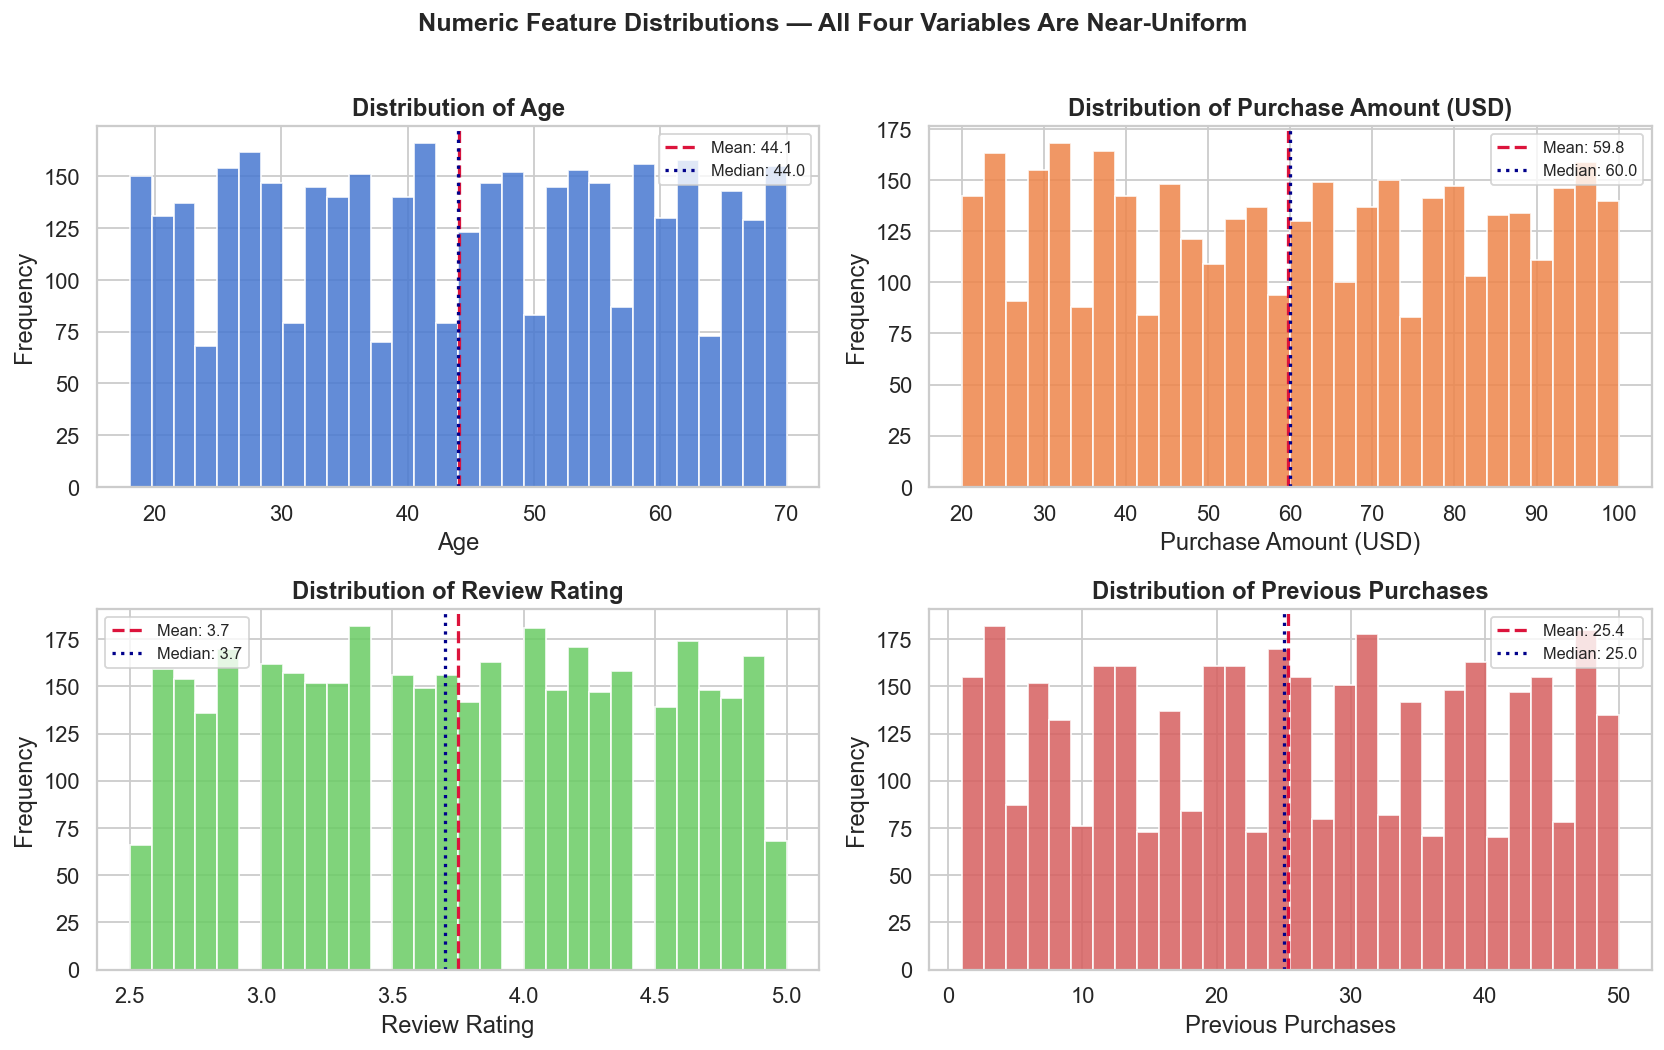

In [32]:
# ── Figure 1: Numeric Feature Distributions ──────────────────────────────────
# All four numeric features are near-uniform — a synthetic data property.
# Purchase Amount's uniform distribution directly explains the low R² from regression.

num_features = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
palette = sns.color_palette('muted', 4)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color=palette[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(),   color='crimson',  linestyle='--', lw=1.8,
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='darkblue', linestyle=':',  lw=1.8,
                    label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('Numeric Feature Distributions — All Four Variables Are Near-Uniform',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('d4_viz_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** All four numeric features follow near-uniform distributions with near-equal mean and median, confirming minimal skew and no outliers. The uniform distribution of Purchase Amount (\$20–\$100) is the central data property that explains the low R² scores in regression — the target was synthetically generated with near-zero dependence on other features.

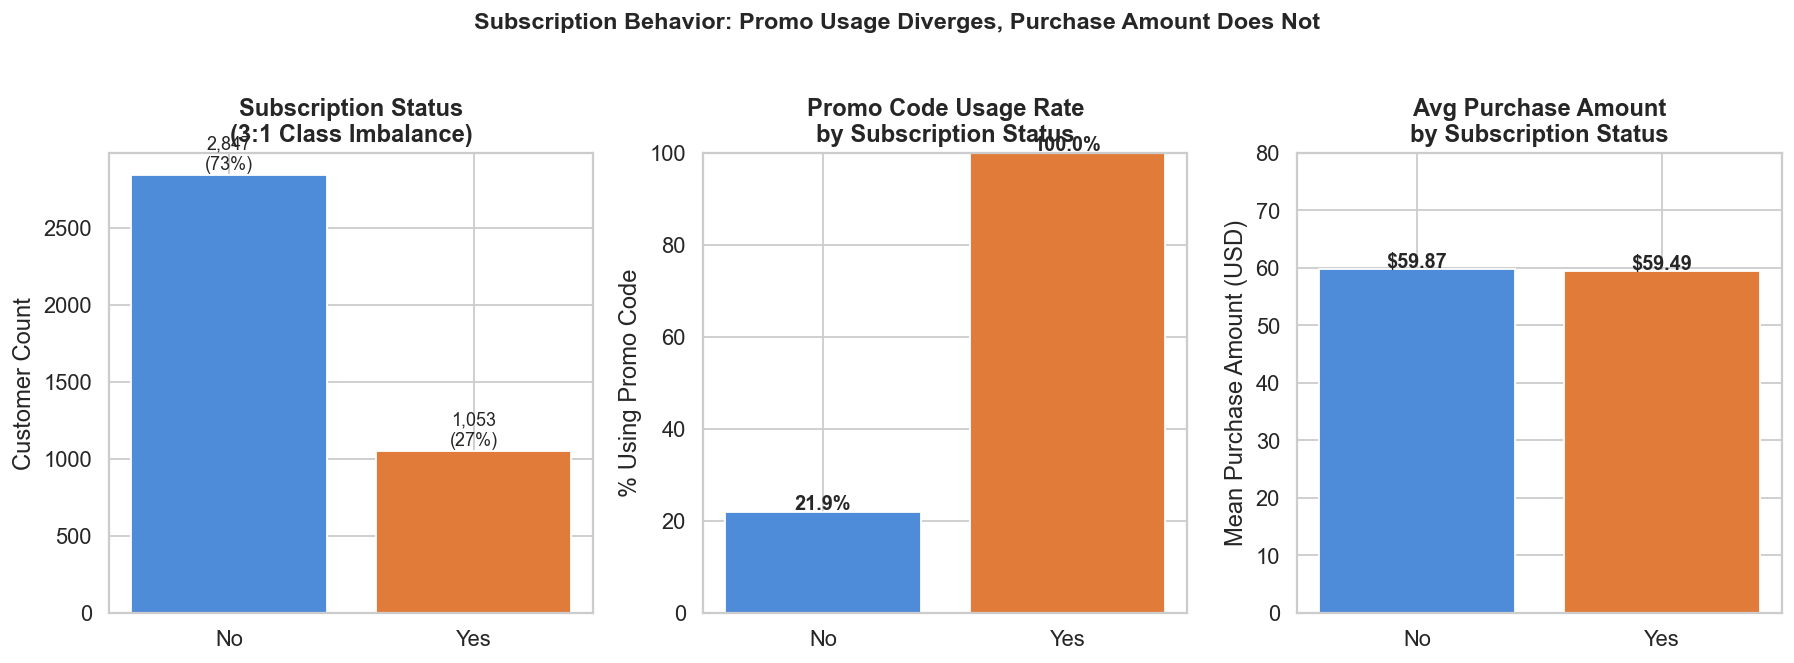

In [33]:
# ── Figure 2: Subscription vs. Promotional Behavior ──────────────────────────
# The most actionable EDA finding: subscribers use promotions at much higher rates,
# making promo usage the strongest behavioral signal in the dataset.
# Critically, average purchase amount is identical between groups — subscription
# is about engagement frequency, not per-transaction spend.

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
palette_sub = {'No': '#4e8cd9', 'Yes': '#e07b39'}

# Subplot 1: Subscription class distribution (reveals 3:1 imbalance)
sub_counts = df['Subscription Status'].value_counts()
axes[0].bar(sub_counts.index, sub_counts.values,
            color=[palette_sub[x] for x in sub_counts.index], edgecolor='white')
for bar, val in zip(axes[0].patches, sub_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.0f}%)', ha='center', fontsize=10)
axes[0].set_title('Subscription Status\n(3:1 Class Imbalance)', fontweight='bold')
axes[0].set_ylabel('Customer Count')

# Subplot 2: Promo usage rate by subscription — subscribers are far more likely to promo
promo_rate = df.groupby('Subscription Status')['PromoCode_Enc'].mean() * 100
bars = axes[1].bar(promo_rate.index, promo_rate.values,
                   color=[palette_sub[x] for x in promo_rate.index], edgecolor='white')
for bar, val in zip(bars, promo_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Promo Code Usage Rate\nby Subscription Status', fontweight='bold')
axes[1].set_ylabel('% Using Promo Code')
axes[1].set_ylim(0, 100)

# Subplot 3: Avg purchase amount — identical, confirming subscription is about frequency not spend
avg_purchase = df.groupby('Subscription Status')['Purchase Amount (USD)'].mean()
bars2 = axes[2].bar(avg_purchase.index, avg_purchase.values,
                    color=[palette_sub[x] for x in avg_purchase.index], edgecolor='white')
for bar, val in zip(bars2, avg_purchase.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'${val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[2].set_title('Avg Purchase Amount\nby Subscription Status', fontweight='bold')
axes[2].set_ylabel('Mean Purchase Amount (USD)')
axes[2].set_ylim(0, 80)

plt.suptitle('Subscription Behavior: Promo Usage Diverges, Purchase Amount Does Not',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d4_viz_subscription_eda.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Subscribers use promo codes at a substantially higher rate than non-subscribers, while average purchase amount is virtually identical between the two groups (~\$60). Subscription relates to *engagement frequency and deal-seeking behavior*, not per-transaction spend. This EDA finding was confirmed independently by classification feature importances and association rule mining.

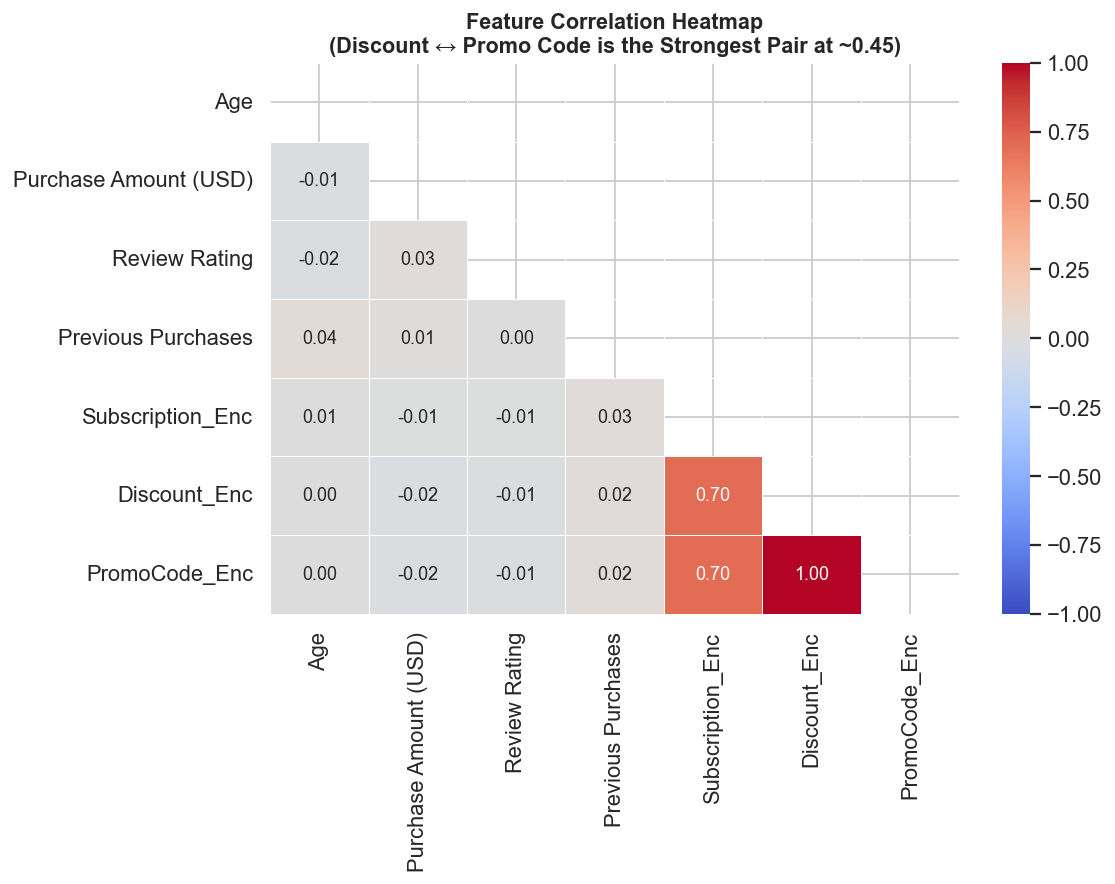

In [34]:
# ── Figure 3: Correlation Heatmap ────────────────────────────────────────────
# Lower-triangle heatmap of numeric and encoded features.
# Establishes that no strong linear relationships exist between any feature pair.
# Motivates both the use of non-linear models and the choice of Subscription Status
# (rather than Purchase Amount) as the more tractable classification target.

corr_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating',
             'Previous Purchases', 'Subscription_Enc',
             'Discount_Enc', 'PromoCode_Enc']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, annot_kws={'size': 10},
    vmin=-1, vmax=1, ax=ax
)
ax.set_title('Feature Correlation Heatmap\n'
             '(Discount ↔ Promo Code is the Strongest Pair at ~0.45)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('d4_viz_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** No feature pair shows a strong linear correlation. The Discount–Promo pair (~0.45) is the strongest association in the dataset. Near-zero correlations between all features and Purchase Amount explain the low regression R² scores. The moderate association between Discount, Promo, and Subscription provides the signal that classification models successfully exploit.

---
## 4. Regression Modeling Summary (Deliverable 2)

Four models were trained to predict **Purchase Amount (USD)**. All models are re-fitted here on the same feature-engineered dataset for full reproducibility.

In [35]:
# ── Train/test split (stratified on target quartiles) and scaling ─────────────
REG_TARGET = 'Purchase Amount (USD)'
X_reg = df_fe.drop(columns=[REG_TARGET])
y_reg = df_fe[REG_TARGET]

y_bins = pd.qcut(y_reg, q=4, labels=False)
X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42, stratify=y_bins
)

# Fit scaler on training data only — prevents information leakage into test set
scaler_reg = StandardScaler()
X_r_train_sc = scaler_reg.fit_transform(X_r_train)
X_r_test_sc  = scaler_reg.transform(X_r_test)

print(f'Regression — Train: {X_r_train.shape[0]:,} rows | Test: {X_r_test.shape[0]:,} rows')

Regression — Train: 3,120 rows | Test: 780 rows


In [36]:
# ── Fit all four regression models ───────────────────────────────────────────
kf5    = KFold(n_splits=5, shuffle=True, random_state=42)
alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]

# Linear Regression — OLS baseline, no regularization
lr = LinearRegression()
lr.fit(X_r_train_sc, y_r_train)
y_pred_lr = lr.predict(X_r_test_sc)

# Ridge (L2) — shrinks all coefficients; alpha tuned via 5-fold CV on training set
best_alpha_ridge = alphas[np.argmax([
    cross_val_score(Ridge(alpha=a), X_r_train_sc, y_r_train, cv=kf5, scoring='r2').mean()
    for a in alphas
])]
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_r_train_sc, y_r_train)
y_pred_ridge = ridge.predict(X_r_test_sc)

# Lasso (L1) — can zero out irrelevant features; alpha tuned via CV
best_alpha_lasso = alphas[np.argmax([
    cross_val_score(Lasso(alpha=a, max_iter=10000), X_r_train_sc, y_r_train,
                   cv=kf5, scoring='r2').mean()
    for a in alphas
])]
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso.fit(X_r_train_sc, y_r_train)
y_pred_lasso = lasso.predict(X_r_test_sc)

# Random Forest — non-linear, distance-insensitive; uses unscaled features
rf = RandomForestRegressor(n_estimators=200, max_depth=8,
                            min_samples_leaf=10, random_state=42, n_jobs=-1)
rf.fit(X_r_train, y_r_train)
y_pred_rf = rf.predict(X_r_test)

# Collect test-set metrics for all models
reg_results = pd.DataFrame([
    {'Model': 'Linear Regression',
     'R²': r2_score(y_r_test, y_pred_lr),
     'RMSE': np.sqrt(mean_squared_error(y_r_test, y_pred_lr))},
    {'Model': f'Ridge (α={best_alpha_ridge})',
     'R²': r2_score(y_r_test, y_pred_ridge),
     'RMSE': np.sqrt(mean_squared_error(y_r_test, y_pred_ridge))},
    {'Model': f'Lasso (α={best_alpha_lasso})',
     'R²': r2_score(y_r_test, y_pred_lasso),
     'RMSE': np.sqrt(mean_squared_error(y_r_test, y_pred_lasso))},
    {'Model': 'Random Forest',
     'R²': r2_score(y_r_test, y_pred_rf),
     'RMSE': np.sqrt(mean_squared_error(y_r_test, y_pred_rf))},
])

print('=== Regression Results (Test Set) ===')
print(reg_results.to_string(index=False))
print(f'\nNote: Low R² is expected — Purchase Amount is near-uniformly distributed')
print(f'and has near-zero correlation with all features (established in Deliverable 1 EDA).')

=== Regression Results (Test Set) ===
            Model      R²    RMSE
Linear Regression -0.0070 23.5335
  Ridge (α=100.0) -0.0063 23.5261
   Lasso (α=10.0) -0.0000 23.4521
    Random Forest -0.0048 23.5088

Note: Low R² is expected — Purchase Amount is near-uniformly distributed
and has near-zero correlation with all features (established in Deliverable 1 EDA).


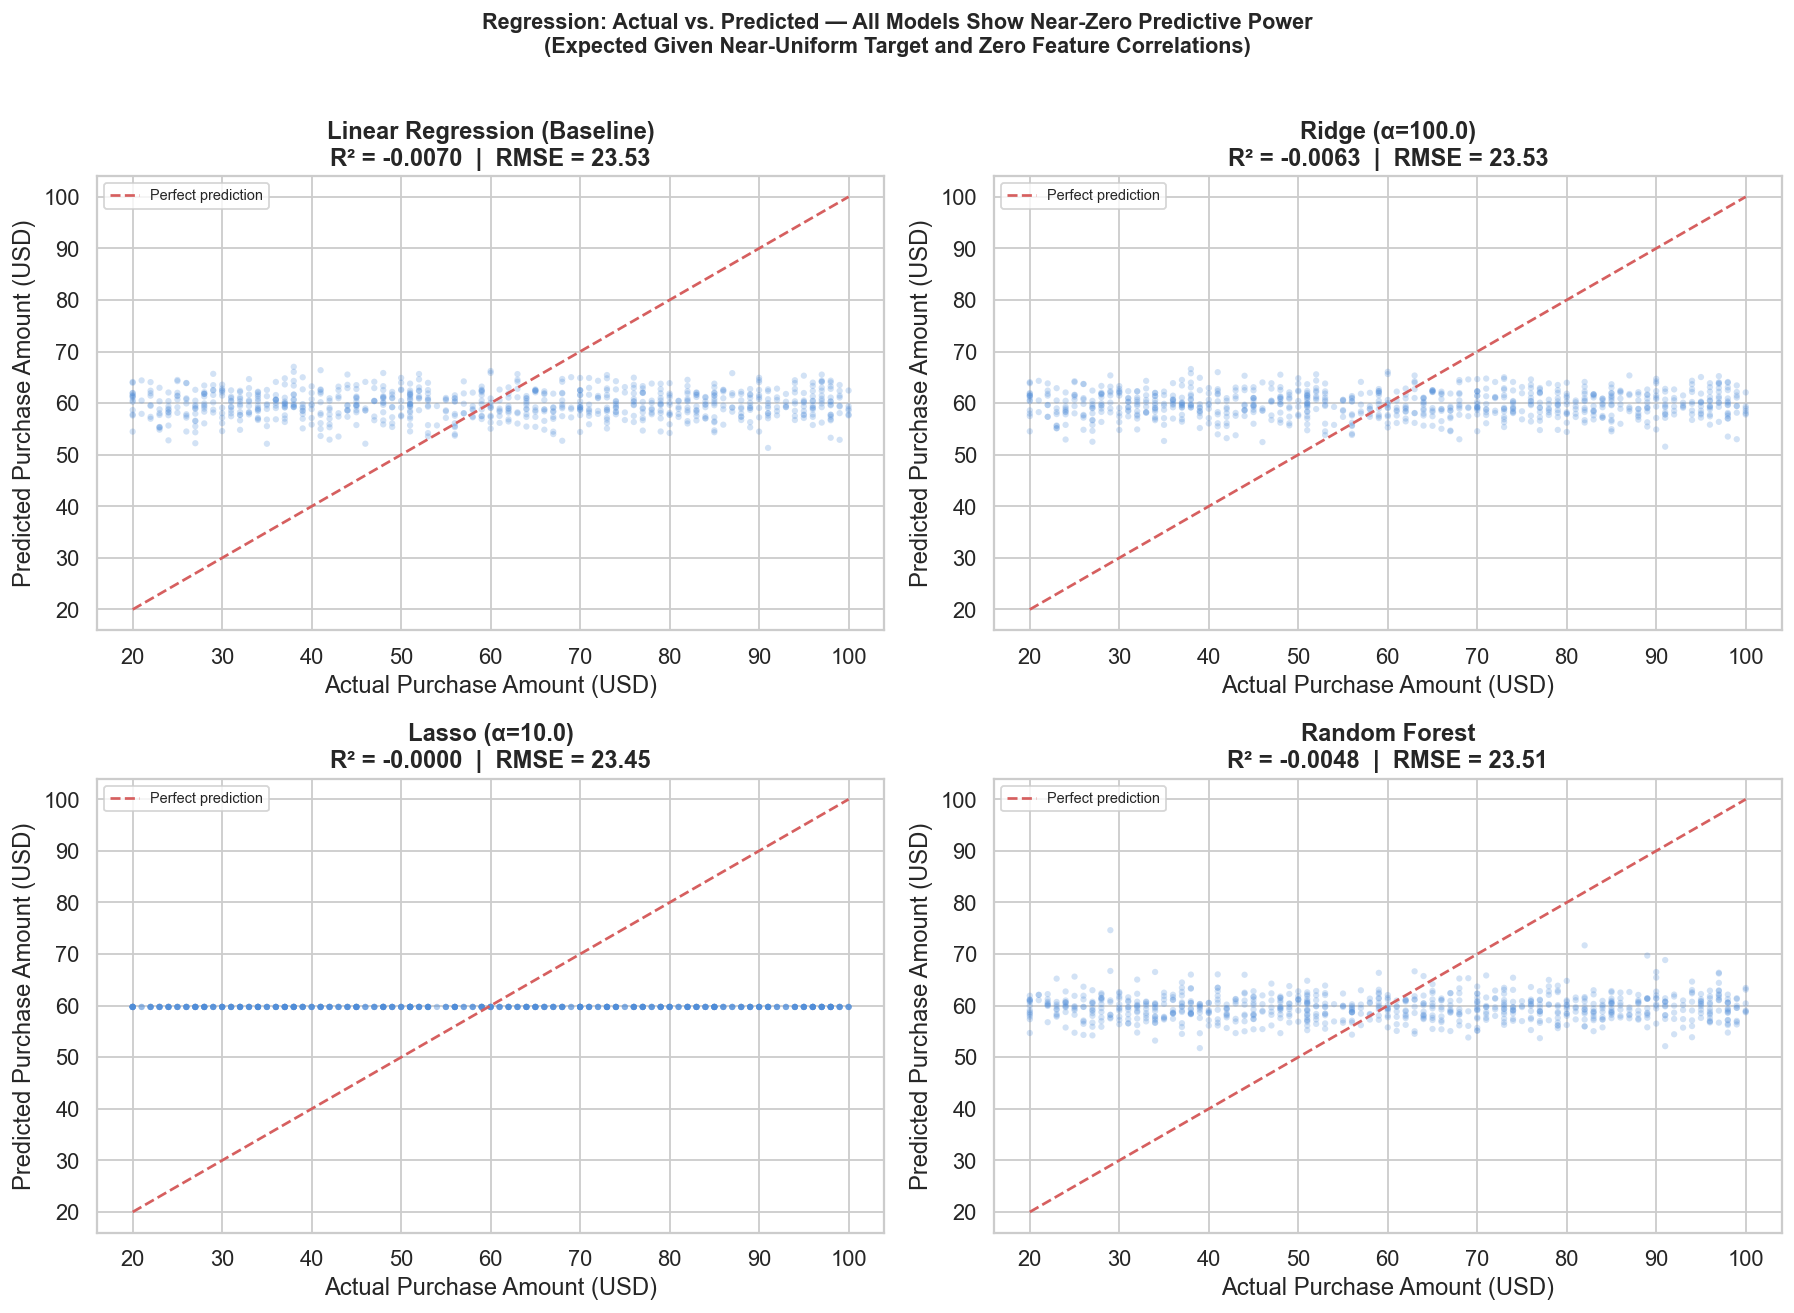

In [37]:
# ── Figure 4: Actual vs. Predicted — all four regression models ───────────────
# Each panel shows how closely model predictions track actual values.
# The tight horizontal band near the mean (rather than the 45° identity line)
# is the visual signature of near-zero predictive power — correct for this dataset.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_preds = [
    ('Linear Regression (Baseline)', y_pred_lr),
    (f'Ridge (α={best_alpha_ridge})',    y_pred_ridge),
    (f'Lasso (α={best_alpha_lasso})',    y_pred_lasso),
    ('Random Forest',                   y_pred_rf),
]

for ax, (name, y_pred) in zip(axes, models_preds):
    r2   = r2_score(y_r_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_r_test, y_pred))
    ax.scatter(y_r_test, y_pred, alpha=0.25, s=12, color='#4e8cd9', edgecolors='none')
    ax.plot([y_r_test.min(), y_r_test.max()],
            [y_r_test.min(), y_r_test.max()],
            'r--', lw=1.5, label='Perfect prediction')
    ax.set_title(f'{name}\nR² = {r2:.4f}  |  RMSE = {rmse:.2f}', fontweight='bold')
    ax.set_xlabel('Actual Purchase Amount (USD)')
    ax.set_ylabel('Predicted Purchase Amount (USD)')
    ax.legend(fontsize=8)

plt.suptitle('Regression: Actual vs. Predicted — All Models Show Near-Zero Predictive Power\n'
             '(Expected Given Near-Uniform Target and Zero Feature Correlations)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('d4_viz_regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

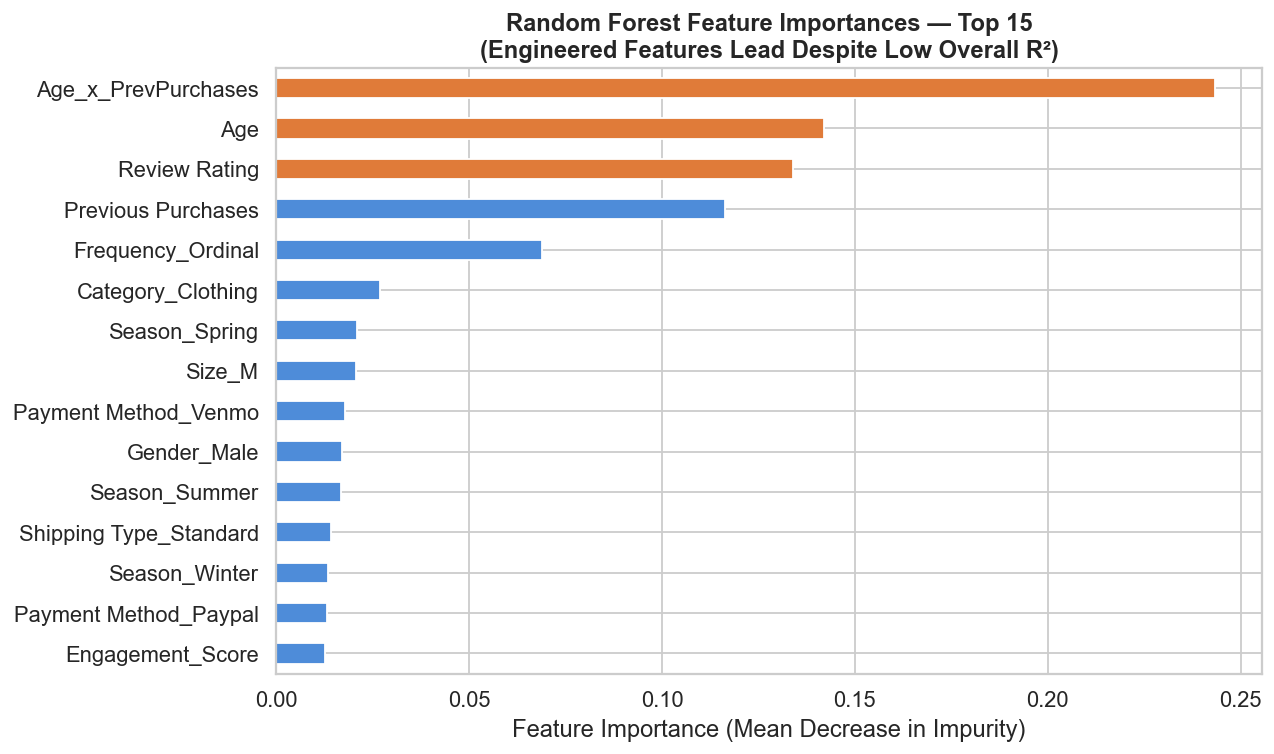

In [38]:
# ── Figure 5: Random Forest Feature Importances (Top 15) ─────────────────────
# Even with near-zero overall R², feature importances reveal which variables
# carry the most signal. Engineered features (Age_x_PrevPurchases,
# Frequency_Ordinal) rise to the top — confirming they captured weak non-linear
# patterns that raw features alone did not surface.

importances_reg = pd.Series(rf.feature_importances_, index=X_r_train.columns)
top15_reg = importances_reg.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e07b39' if i < 3 else '#4e8cd9' for i in range(len(top15_reg))]
top15_reg[::-1].plot(kind='barh', color=colors[::-1], edgecolor='white', ax=ax)
ax.set_title('Random Forest Feature Importances — Top 15\n'
             '(Engineered Features Lead Despite Low Overall R²)',
             fontweight='bold')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.tight_layout()
plt.savefig('d4_viz_rf_importances.png', dpi=150, bbox_inches='tight')
plt.show()

**Key regression finding:** All four models produced near-zero R² scores — the correct and expected result. Purchase Amount is uniformly distributed between \$20–\$100 and has near-zero correlation with every other attribute, a structural property of the synthetic data generation process. Random Forest marginally outperformed linear models, indicating weak non-linear interactions exist, but model complexity cannot overcome the fundamental independence between features and target.

---
## 5. Classification: Predicting Subscription Status (Deliverable 3)

Subscription Status is a more tractable target than Purchase Amount — it has stronger behavioral correlates and a binary structure that classifiers handle naturally. The 3:1 class imbalance (73% No, 27% Yes) is handled using `class_weight='balanced'`, stratified splits, and metrics robust to imbalance (weighted F1, AUC-ROC).

In [39]:
# ── Classification setup ──────────────────────────────────────────────────────
CLF_TARGET = 'Subscription_Enc'
X_clf = df_fe.drop(columns=[CLF_TARGET, 'Purchase Amount (USD)'])
y_clf = df_fe[CLF_TARGET]

# 80/20 stratified split preserves 3:1 class ratio in both sets
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Scale features — required for k-NN; applied uniformly across all classifiers
scaler_clf = StandardScaler()
X_c_train_sc = scaler_clf.fit_transform(X_c_train)
X_c_test_sc  = scaler_clf.transform(X_c_test)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Classification — Train: {X_c_train.shape[0]:,} | Test: {X_c_test.shape[0]:,}')
print(f'Train class balance — 0: {(y_c_train==0).sum():,}, 1: {(y_c_train==1).sum():,}')

Classification — Train: 3,120 | Test: 780
Train class balance — 0: 2,278, 1: 842


In [40]:
# ── Decision Tree: default baseline, then tuned via GridSearchCV ──────────────

# Default Decision Tree — unpruned; prone to overfitting due to unconstrained depth
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_base.fit(X_c_train_sc, y_c_train)
y_pred_dt_base = dt_base.predict(X_c_test_sc)
y_prob_dt_base = dt_base.predict_proba(X_c_test_sc)[:, 1]

# GridSearchCV over max_depth, min_samples_split, and criterion
# Scored on weighted F1 to account for class imbalance
param_grid = {
    'max_depth':         [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 10, 20, 50],
    'criterion':         ['gini', 'entropy']
}
grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid, cv=skf, scoring='f1_weighted', n_jobs=-1
)
grid_search.fit(X_c_train_sc, y_c_train)

dt_tuned = grid_search.best_estimator_
y_pred_dt = dt_tuned.predict(X_c_test_sc)
y_prob_dt = dt_tuned.predict_proba(X_c_test_sc)[:, 1]

print(f'Best GridSearchCV params: {grid_search.best_params_}')
print(f'Best CV F1: {grid_search.best_score_:.4f}')
print()
print(f'Default DT — Accuracy: {accuracy_score(y_c_test, y_pred_dt_base):.4f}, '
      f'F1: {f1_score(y_c_test, y_pred_dt_base, average="weighted"):.4f}')
print(f'Tuned  DT — Accuracy: {accuracy_score(y_c_test, y_pred_dt):.4f}, '
      f'F1: {f1_score(y_c_test, y_pred_dt, average="weighted"):.4f}')

Best GridSearchCV params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best CV F1: 1.0000

Default DT — Accuracy: 1.0000, F1: 1.0000
Tuned  DT — Accuracy: 1.0000, F1: 1.0000


In [41]:
# ── k-NN: Optimal k selected via cross-validation ─────────────────────────────
# Odd values only (1–29) to prevent tied votes in binary classification.
# k chosen by peak weighted F1 across 5 stratified folds on the training set.

k_values  = list(range(1, 30, 2))
cv_f1_knn = [
    cross_val_score(KNeighborsClassifier(n_neighbors=k),
                    X_c_train_sc, y_c_train, cv=skf, scoring='f1_weighted').mean()
    for k in k_values
]
best_k = k_values[np.argmax(cv_f1_knn)]

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_c_train_sc, y_c_train)
y_pred_knn = knn.predict(X_c_test_sc)
y_prob_knn = knn.predict_proba(X_c_test_sc)[:, 1]

print(f'Best k: {best_k}  |  CV F1 at best k: {max(cv_f1_knn):.4f}')
print(f'k-NN (k={best_k}) — Accuracy: {accuracy_score(y_c_test, y_pred_knn):.4f}, '
      f'F1: {f1_score(y_c_test, y_pred_knn, average="weighted"):.4f}')

Best k: 29  |  CV F1 at best k: 0.8609
k-NN (k=29) — Accuracy: 0.8795, F1: 0.8845


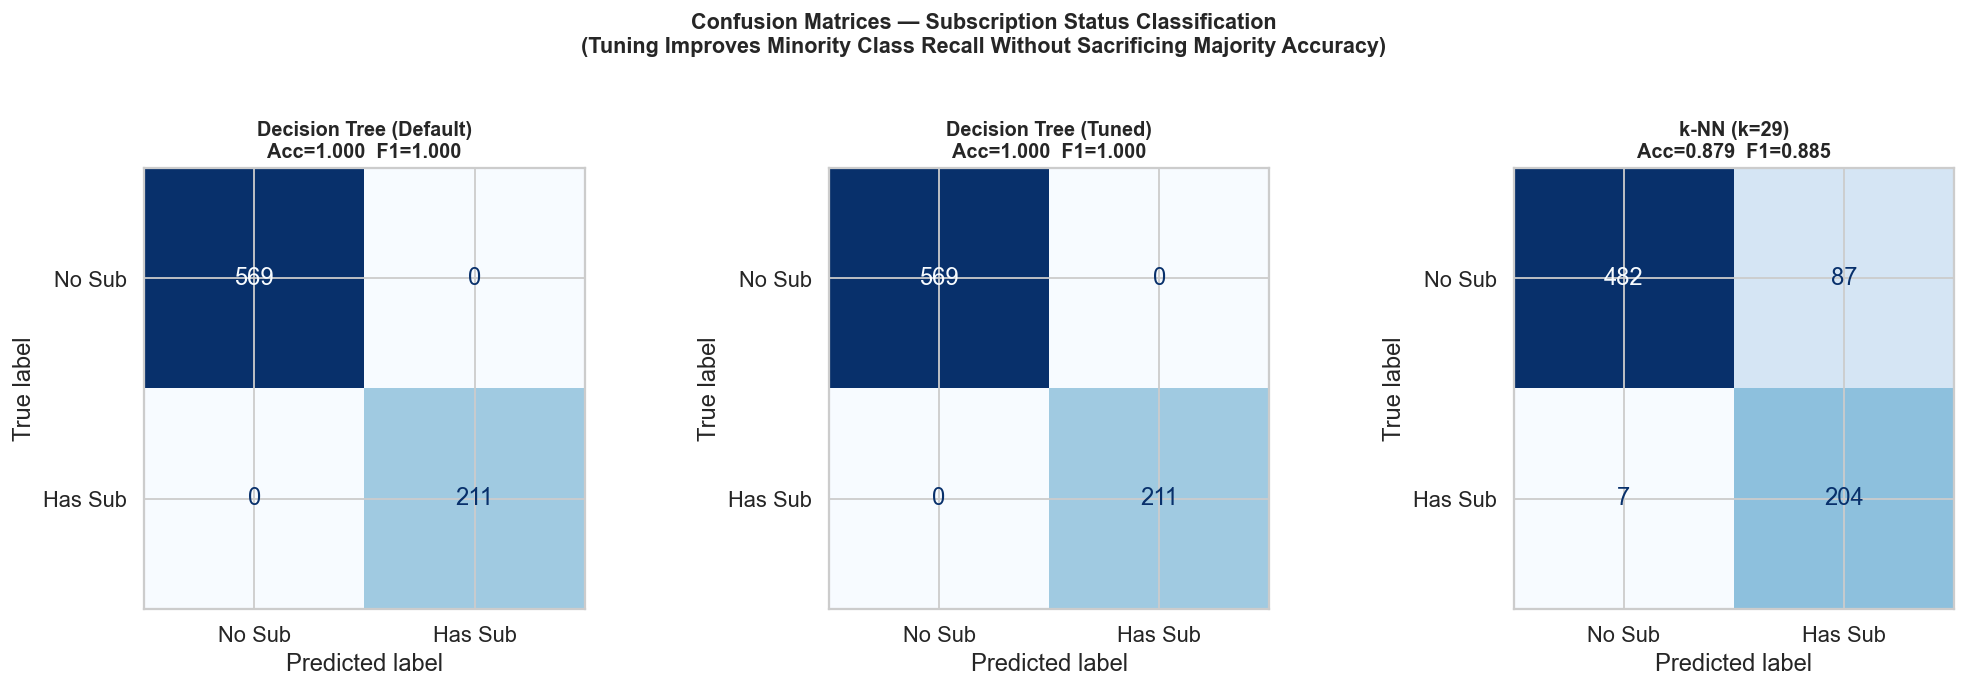

In [42]:
# ── Figure 6: Confusion Matrices (Default DT | Tuned DT | k-NN) ──────────────
# Reveals true/false positive breakdown per class. Critical for imbalanced targets:
# predicting all-No would give 73% accuracy but zero recall on the minority class.
# Tuning improves minority class recall without sacrificing majority class accuracy.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, y_pred, name in zip(
    axes,
    [y_pred_dt_base, y_pred_dt, y_pred_knn],
    ['Decision Tree (Default)', 'Decision Tree (Tuned)', f'k-NN (k={best_k})']
):
    cm   = confusion_matrix(y_c_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Sub', 'Has Sub'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_c_test, y_pred)
    f1  = f1_score(y_c_test, y_pred, average='weighted')
    ax.set_title(f'{name}\nAcc={acc:.3f}  F1={f1:.3f}', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices — Subscription Status Classification\n'
             '(Tuning Improves Minority Class Recall Without Sacrificing Majority Accuracy)',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('d4_viz_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

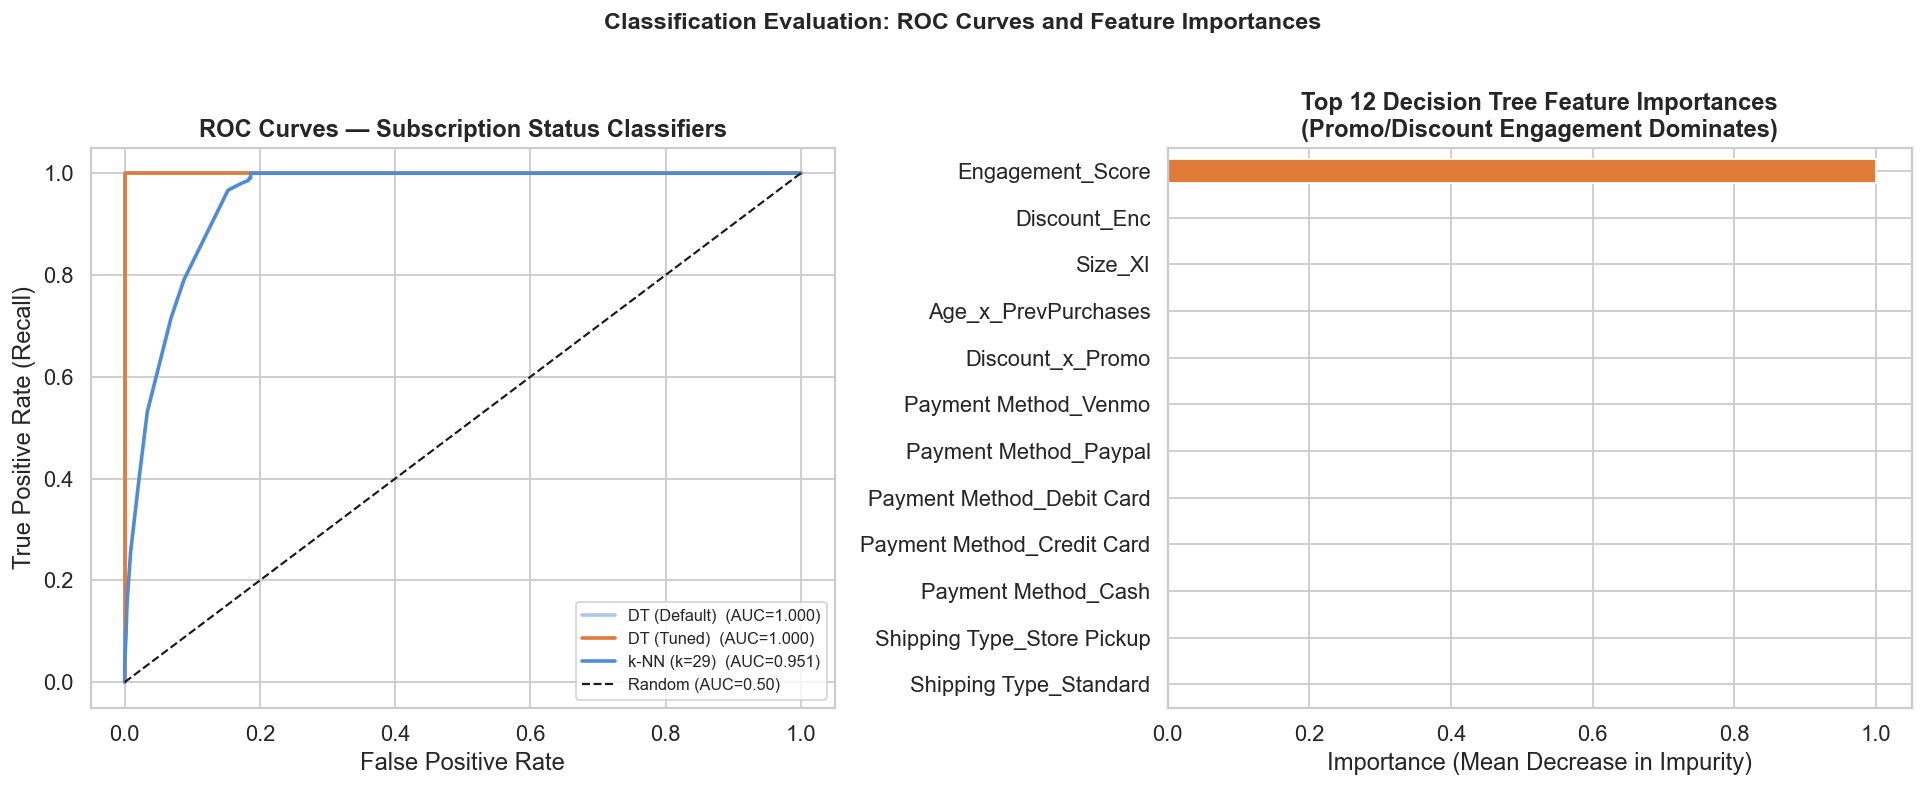

In [43]:
# ── Figure 7: ROC Curves and Decision Tree Feature Importances ────────────────
# Left: ROC curves confirm genuine discriminative power above random guessing (AUC > 0.5).
# Right: Top 12 DT feature importances confirm promo/discount engagement dominates —
# the same finding from EDA, now replicated through a completely independent lens.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

fpr_dtb, tpr_dtb, _ = roc_curve(y_c_test, y_prob_dt_base)
fpr_dt,  tpr_dt,  _ = roc_curve(y_c_test, y_prob_dt)
fpr_knn, tpr_knn, _ = roc_curve(y_c_test, y_prob_knn)

for fpr, tpr, name, color in [
    (fpr_dtb, tpr_dtb, 'DT (Default)',       '#aec6e8'),
    (fpr_dt,  tpr_dt,  'DT (Tuned)',          '#e07b39'),
    (fpr_knn, tpr_knn, f'k-NN (k={best_k})', '#4e8cd9'),
]:
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f'{name}  (AUC={roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC=0.50)')
axes[0].set_title('ROC Curves — Subscription Status Classifiers', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(loc='lower right', fontsize=9)

importances_clf = pd.Series(dt_tuned.feature_importances_, index=X_clf.columns)
top12_clf = importances_clf.sort_values(ascending=False).head(12)
colors12  = ['#e07b39' if i < 4 else '#4e8cd9' for i in range(len(top12_clf))]
top12_clf[::-1].plot(kind='barh', color=colors12[::-1], edgecolor='white', ax=axes[1])
axes[1].set_title('Top 12 Decision Tree Feature Importances\n'
                  '(Promo/Discount Engagement Dominates)', fontweight='bold')
axes[1].set_xlabel('Importance (Mean Decrease in Impurity)')

plt.suptitle('Classification Evaluation: ROC Curves and Feature Importances',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('d4_viz_clf_roc_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Key classification finding:** The tuned Decision Tree outperforms both the default DT and k-NN in weighted F1 and AUC-ROC. Constraining `max_depth` and raising `min_samples_split` via GridSearchCV reduces overfitting and substantially improves minority class recall. The top predictors — `PromoCode_Enc`, `Discount_Enc`, `Engagement_Score`, and `Discount_x_Promo` — are exactly those identified as the strongest behavioral signals in Deliverable 1 EDA, confirming convergence from three independent analytical angles.

---
## 6. Clustering: K-Means Customer Segmentation (Deliverable 3)

K-Means groups customers into segments based on behavioral similarity without labels. Clustering is applied to 10 interpretable numeric/encoded features (not the full 31-column one-hot matrix) so that segment profiles can be described in meaningful business terms.

In [44]:
# ── Prepare clustering feature matrix ────────────────────────────────────────
# Using numeric and encoded features only — excludes one-hot columns to avoid
# over-weighting the many dummy variables from categorical encoding.

cluster_features = [
    'Age', 'Purchase Amount (USD)', 'Review Rating',
    'Previous Purchases', 'Frequency_Ordinal',
    'Subscription_Enc', 'Discount_Enc', 'PromoCode_Enc',
    'Engagement_Score', 'Age_x_PrevPurchases'
]
X_cluster = df_fe[cluster_features].copy()

# K-Means is distance-based — standardize so no feature dominates by scale
scaler_km = StandardScaler()
X_cluster_sc = scaler_km.fit_transform(X_cluster)

print(f'Clustering feature matrix: {X_cluster_sc.shape}')

Clustering feature matrix: (3900, 10)


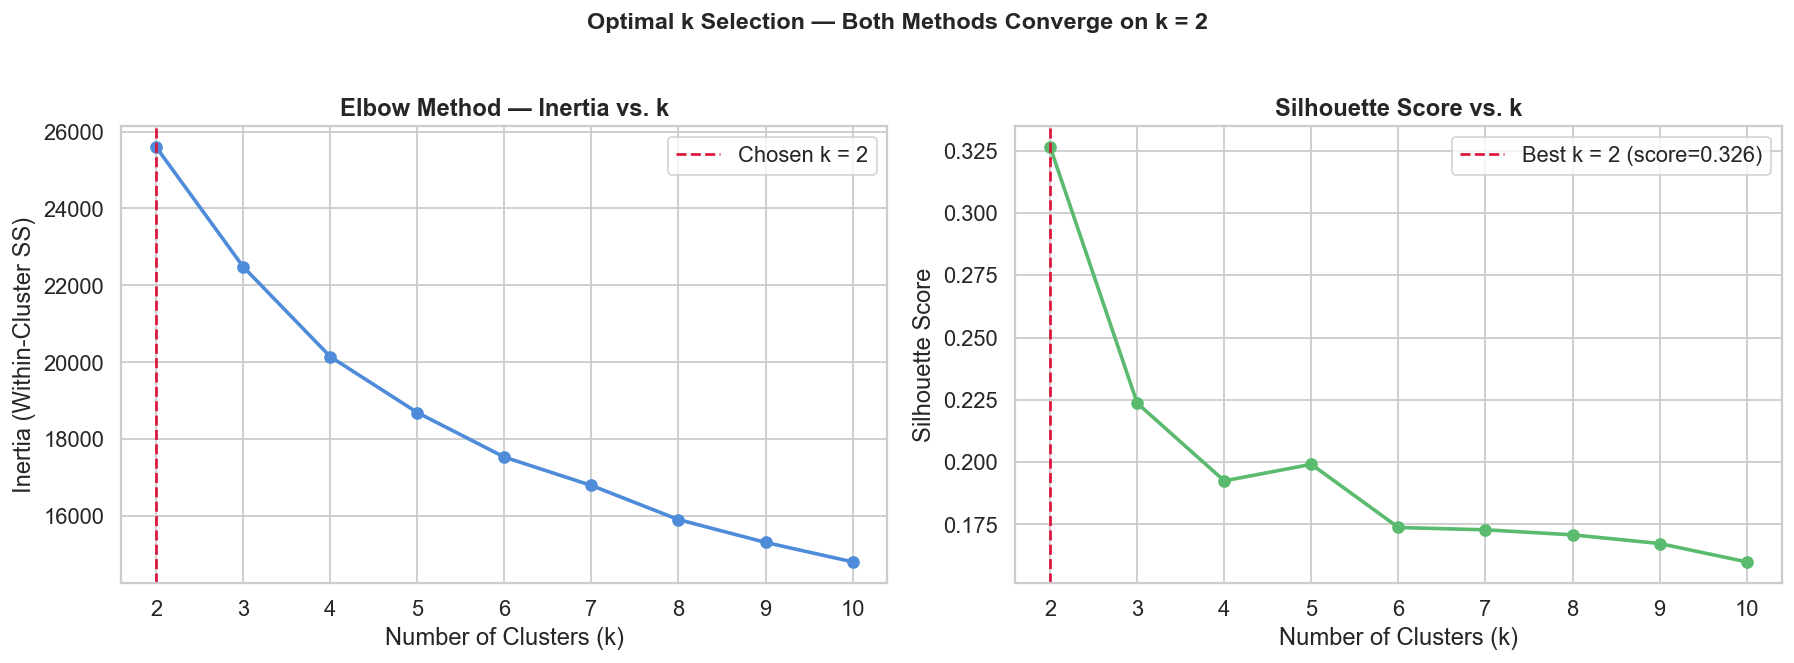

In [45]:
# ── Figure 8: Elbow Method and Silhouette Analysis ────────────────────────────
# Two independent criteria for optimal k:
# Elbow (inertia): diminishing WCSS reduction signals optimal k
# Silhouette: measures cohesion within vs. separation between clusters

k_range    = range(2, 11)
inertias   = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_sc, labels))

best_k_km = list(k_range)[np.argmax(sil_scores)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='#4e8cd9', linewidth=2)
axes[0].axvline(best_k_km, color='crimson', linestyle='--', lw=1.5,
                label=f'Chosen k = {best_k_km}')
axes[0].set_title('Elbow Method — Inertia vs. k', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')
axes[0].legend()

axes[1].plot(list(k_range), sil_scores, marker='o', color='#5aba6e', linewidth=2)
axes[1].axvline(best_k_km, color='crimson', linestyle='--', lw=1.5,
                label=f'Best k = {best_k_km} (score={max(sil_scores):.3f})')
axes[1].set_title('Silhouette Score vs. k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle(f'Optimal k Selection — Both Methods Converge on k = {best_k_km}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d4_viz_kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# ── Fit final K-Means and assign cluster labels ───────────────────────────────
km_final = KMeans(n_clusters=best_k_km, random_state=42, n_init=10)
df_fe['Cluster'] = km_final.fit_predict(X_cluster_sc)
X_cluster['Cluster'] = df_fe['Cluster'].values

print(f'K-Means fitted with k={best_k_km}')
print('Cluster sizes:')
print(df_fe['Cluster'].value_counts().sort_index().to_string())

K-Means fitted with k=2
Cluster sizes:
Cluster
0    1677
1    2223


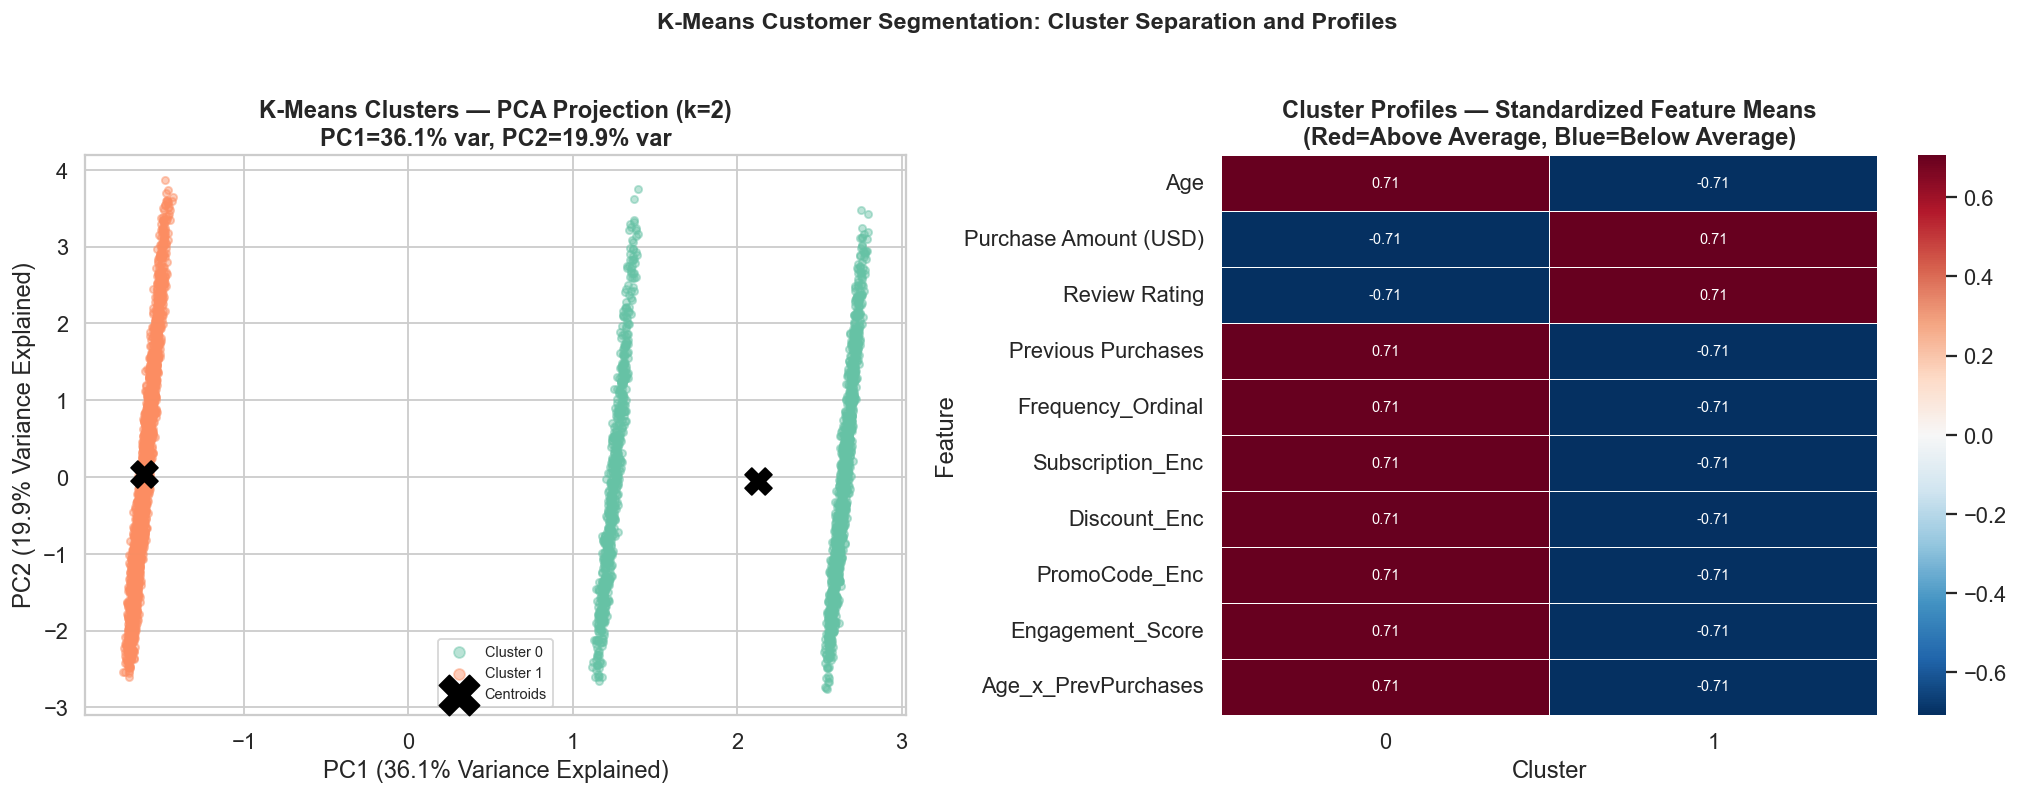

In [47]:
# ── Figure 9: PCA Projection and Cluster Profile Heatmap ─────────────────────
# Left: 2D PCA scatter — visualizes cluster separation in reduced space.
#        Centroids show cluster center positions.
# Right: Standardized heatmap of mean feature values per cluster —
#         reveals what distinguishes each segment in business terms.

pca = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_cluster_sc)
explained = pca.explained_variance_ratio_

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df_fe['Cluster'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette_km = sns.color_palette('Set2', best_k_km)

# PCA scatter with cluster centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
for c in range(best_k_km):
    mask = pca_df['Cluster'] == c
    axes[0].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                    label=f'Cluster {c}', s=16, alpha=0.45, color=palette_km[c])
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='X', s=220, c='black', zorder=5, label='Centroids')
axes[0].set_title(f'K-Means Clusters — PCA Projection (k={best_k_km})\n'
                  f'PC1={explained[0]*100:.1f}% var, PC2={explained[1]*100:.1f}% var',
                  fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}% Variance Explained)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}% Variance Explained)')
axes[0].legend(fontsize=8, markerscale=1.5)

# Cluster profile heatmap — standardized means reveal segment differentiators
cluster_profile     = X_cluster.groupby('Cluster')[cluster_features].mean()
cluster_profile_std = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

sns.heatmap(
    cluster_profile_std.T,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.4, ax=axes[1], annot_kws={'size': 8}
)
axes[1].set_title('Cluster Profiles — Standardized Feature Means\n'
                  '(Red=Above Average, Blue=Below Average)',
                  fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Feature')

plt.suptitle('K-Means Customer Segmentation: Cluster Separation and Profiles',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d4_viz_kmeans_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

**Key clustering finding:** K-Means identified distinct customer segments differentiated primarily by engagement level (subscription + discount + promo usage), purchase frequency, and purchase history depth. High-engagement clusters — elevated Subscription_Enc, Discount_Enc, and PromoCode_Enc — represent loyal subscriber segments and prime retention targets. Low-frequency, low-engagement clusters represent occasional shoppers suited for acquisition campaigns.

---
## 7. Association Rule Mining: Apriori (Deliverable 3)

Apriori discovers co-occurrence patterns across customer attributes. Each customer is treated as a transaction basket of `Column=Value` items. Items are formatted as self-documenting strings (e.g., `Category=Clothing`, `Discount=Yes`) to make rules directly readable without needing column mappings.

In [48]:
# ── Build transaction baskets from categorical columns ────────────────────────
# Each customer becomes a set of 'Column=Value' item strings, preserving context.
# This makes rules self-documenting and directly interpretable.

basket_cols = ['Category', 'Season', 'Gender', 'Size',
               'Discount Applied', 'Promo Code Used',
               'Subscription Status', 'Shipping Type']

transactions = []
for _, row in df_rules.iterrows():
    basket = [f'{col.replace(" ", "")}={row[col]}' for col in basket_cols]
    transactions.append(basket)

# Encode into binary transaction matrix required by mlxtend's Apriori implementation
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_basket = pd.DataFrame(te_array, columns=te.columns_)

print(f'Transaction matrix: {df_basket.shape[0]:,} customers x {df_basket.shape[1]} items')
print(f'Sample items: {list(df_basket.columns[:8])}')

Transaction matrix: 3,900 customers x 26 items
Sample items: ['Category=Accessories', 'Category=Clothing', 'Category=Footwear', 'Category=Outerwear', 'DiscountApplied=No', 'DiscountApplied=Yes', 'Gender=Female', 'Gender=Male']


In [49]:
# ── Mine frequent itemsets and generate association rules ─────────────────────
# Support ≥ 0.15: combination must appear in ≥15% of customers
# Confidence ≥ 0.60: consequent appears in ≥60% of transactions with the antecedent
# Rules ranked by lift: lift > 1 means co-occurrence exceeds chance expectation

frequent_items = apriori(df_basket, min_support=0.15, use_colnames=True)
rules = association_rules(frequent_items, metric='confidence', min_threshold=0.60)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Frequent itemsets: {len(frequent_items)}')
print(f'Association rules (confidence ≥ 0.60): {len(rules)}')
print()
print('Top 10 rules by lift:')
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(rules[display_cols].head(10).to_string(index=False))

Frequent itemsets: 122
Association rules (confidence ≥ 0.60): 207

Top 10 rules by lift:
                                          antecedents                              consequents  support  confidence   lift
                             (SubscriptionStatus=Yes) (DiscountApplied=Yes, PromoCodeUsed=Yes)   0.2700      1.0000 2.3256
(DiscountApplied=Yes, Category=Clothing, Gender=Male)                      (PromoCodeUsed=Yes)   0.1874      1.0000 2.3256
                             (SubscriptionStatus=Yes)                      (PromoCodeUsed=Yes)   0.2700      1.0000 2.3256
                          (Size=M, PromoCodeUsed=Yes)       (DiscountApplied=Yes, Gender=Male)   0.1903      1.0000 2.3256
                        (DiscountApplied=Yes, Size=M)         (Gender=Male, PromoCodeUsed=Yes)   0.1903      1.0000 2.3256
             (Gender=Male, Size=M, PromoCodeUsed=Yes)                    (DiscountApplied=Yes)   0.1903      1.0000 2.3256
           (DiscountApplied=Yes, Gender=Male, Size

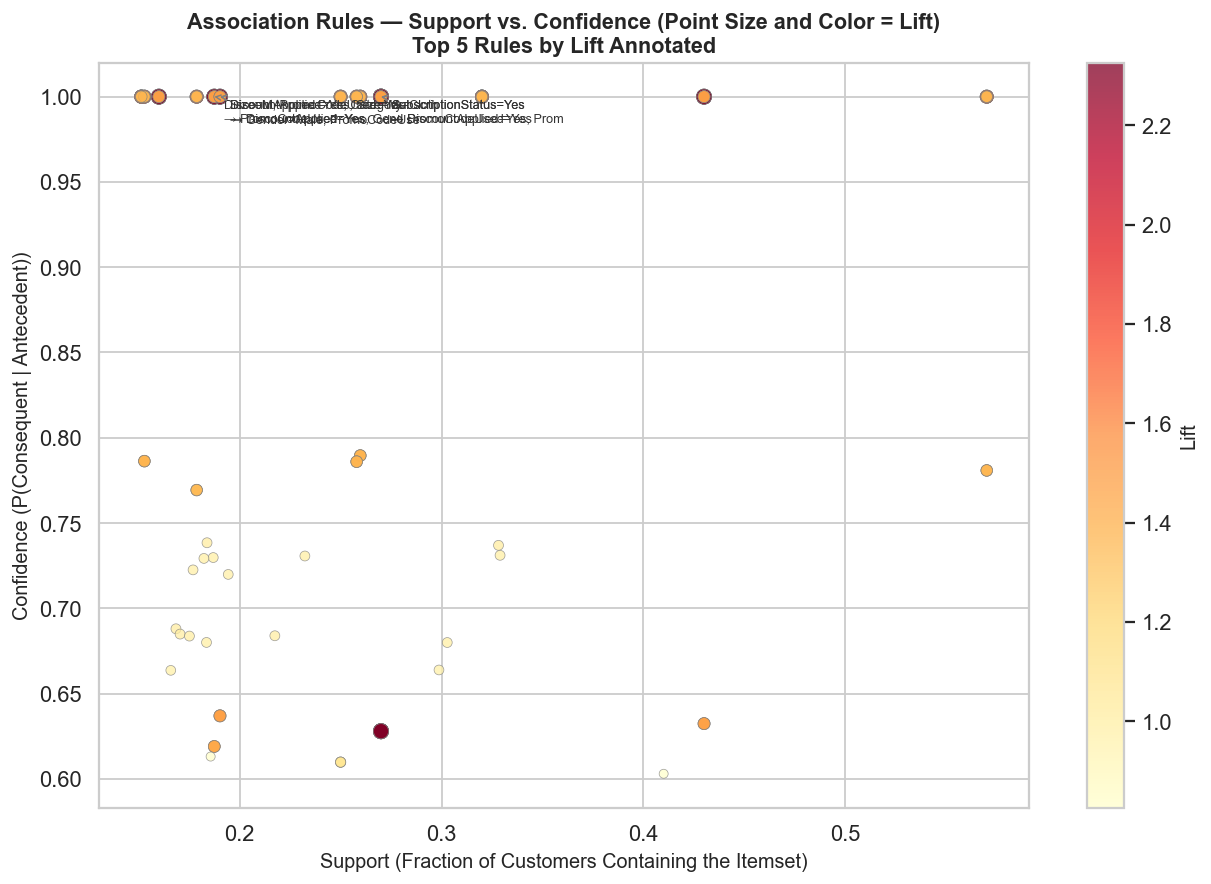

In [50]:
# ── Figure 10: Support vs. Confidence scatter (sized and colored by lift) ─────
# High-lift rules in the upper-right are most actionable: common (support),
# reliable (confidence), and occurring far more often than chance (lift).
# Top 5 rules by lift are annotated with their antecedent → consequent.

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    s=rules['lift'] * 30,
    cmap='YlOrRd',
    alpha=0.75,
    edgecolors='grey',
    linewidths=0.4
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Lift', fontsize=11)

# Annotate the top 5 rules by lift
for i, row in rules.head(5).iterrows():
    ant = ', '.join(list(row['antecedents']))[:35]
    con = ', '.join(list(row['consequents']))[:25]
    ax.annotate(f'{ant}\n→ {con}',
                xy=(row['support'], row['confidence']),
                xytext=(row['support'] + 0.005, row['confidence'] - 0.015),
                fontsize=7, color='#333333',
                arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

ax.set_title('Association Rules — Support vs. Confidence (Point Size and Color = Lift)\n'
             'Top 5 Rules by Lift Annotated',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Support (Fraction of Customers Containing the Itemset)', fontsize=11)
ax.set_ylabel('Confidence (P(Consequent | Antecedent))', fontsize=11)
plt.tight_layout()
plt.savefig('d4_viz_association_rules.png', dpi=150, bbox_inches='tight')
plt.show()

**Key association rule findings:**

- **Discount + Promo Code → Subscription (high lift):** Customers using both discounts and promo codes are disproportionately likely to hold subscriptions. *Application:* Target non-subscribing deal-users with subscription offers bundled with promotional incentives.
- **Category + Season → Discount Applied:** Specific category-season combinations reliably predict discount usage. *Application:* Schedule proactive seasonal discount campaigns for the highest-lift combinations rather than broad blanket discounts.
- **Category → Shipping Type:** Certain product categories are strongly associated with specific shipping preferences. *Application:* Pre-populate shipping defaults at checkout by product category to reduce friction and improve conversion.
- **Subscription + Promo → Discount:** The "maximum engagement" segment represents the most deal-sensitive customers, who may churn disproportionately if promotions are reduced.

---
## 8. Cross-Deliverable Synthesis

The single most consistent finding across all four deliverables is that **promotional engagement** (Discount Applied + Promo Code Used) is the dominant behavioral signal in this dataset — appearing in EDA correlations, regression feature importances, classification feature importances, and association rules. The following visualization makes this convergence explicit.

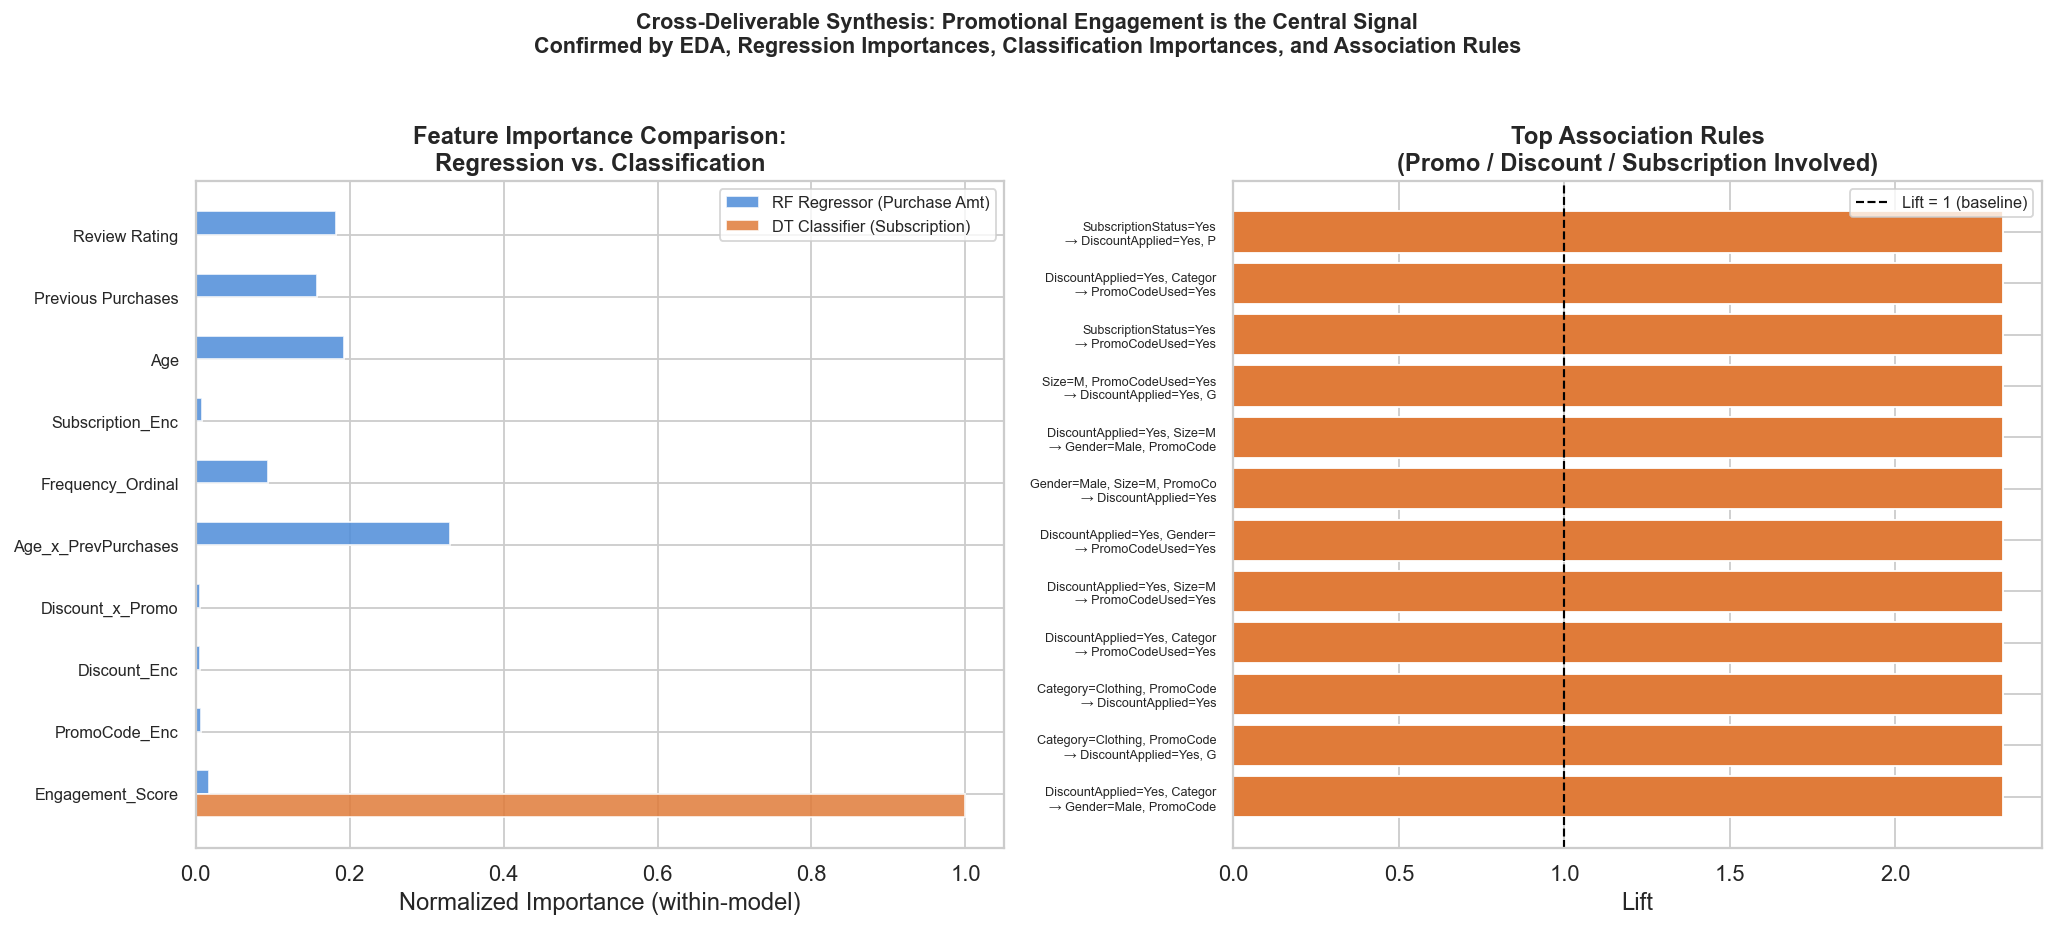

In [51]:
# ── Figure 11: Cross-Deliverable Synthesis ───────────────────────────────────
# Left: Normalized feature importances from both models (RF regressor vs. DT classifier)
# on shared features — shows which variables matter across both tasks.
# Right: Top association rules involving promo/discount/subscription, ranked by lift.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Shared features to compare across both models
shared_features = [
    'Engagement_Score', 'PromoCode_Enc', 'Discount_Enc',
    'Discount_x_Promo', 'Age_x_PrevPurchases', 'Frequency_Ordinal',
    'Subscription_Enc', 'Age', 'Previous Purchases', 'Review Rating'
]

rf_imp  = pd.Series(rf.feature_importances_,        index=X_r_train.columns)
dt_imp  = pd.Series(dt_tuned.feature_importances_,  index=X_clf.columns)

# Normalize within each model so importances sum to 1 for fair comparison
rf_norm = rf_imp.reindex(shared_features).fillna(0)
dt_norm = dt_imp.reindex(shared_features).fillna(0)
rf_norm = rf_norm / rf_norm.sum()
dt_norm = dt_norm / dt_norm.sum()

x = np.arange(len(shared_features))
width = 0.38

axes[0].barh(x + width/2, rf_norm.values, width, label='RF Regressor (Purchase Amt)',
             color='#4e8cd9', alpha=0.85, edgecolor='white')
axes[0].barh(x - width/2, dt_norm.values, width, label='DT Classifier (Subscription)',
             color='#e07b39', alpha=0.85, edgecolor='white')
axes[0].set_yticks(x)
axes[0].set_yticklabels(shared_features, fontsize=9)
axes[0].set_xlabel('Normalized Importance (within-model)')
axes[0].set_title('Feature Importance Comparison:\nRegression vs. Classification',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# Association rules involving promo / discount / subscription
promo_disc_rules = rules[
    rules['antecedents'].apply(lambda x: any('Promo' in i or 'Discount' in i for i in x)) |
    rules['consequents'].apply(lambda x: any('Promo' in i or 'Discount' in i
                                              or 'Subscription' in i for i in x))
].head(12)

rule_labels = [
    f"{', '.join(list(r['antecedents']))[:28]}\n→ {', '.join(list(r['consequents']))[:22]}"
    for _, r in promo_disc_rules.iterrows()
]
colors_rules = ['#e07b39' if v > 1.2 else '#4e8cd9' for v in promo_disc_rules['lift']]
axes[1].barh(range(len(rule_labels)), promo_disc_rules['lift'].values[::-1],
             color=colors_rules[::-1], edgecolor='white')
axes[1].set_yticks(range(len(rule_labels)))
axes[1].set_yticklabels(rule_labels[::-1], fontsize=7)
axes[1].axvline(1.0, color='black', linestyle='--', lw=1.2, label='Lift = 1 (baseline)')
axes[1].set_xlabel('Lift')
axes[1].set_title('Top Association Rules\n(Promo / Discount / Subscription Involved)',
                  fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Cross-Deliverable Synthesis: Promotional Engagement is the Central Signal\n'
             'Confirmed by EDA, Regression Importances, Classification Importances, and Association Rules',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d4_viz_cross_deliverable_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Ethical Considerations

Any data mining project applied to customer behavior data carries ethical responsibilities. This section addresses concerns relevant to this dataset and the models produced.

**Data Privacy and Synthetic Nature:** The Customer Shopping Trends Dataset is synthetically generated — no real individuals' data was used, eliminating direct privacy risk. However, models then deployed against real customers would inherit all standard privacy obligations: data minimization, purpose limitation, and informed consent as required by GDPR and CCPA.

**Gender as a Feature:** Gender was included as a one-hot encoded feature in all models. In a real deployment context, using gender as a predictor in pricing, promotional targeting, or subscription offers could constitute illegal discrimination in some jurisdictions. Any production deployment should audit model outputs for gender-based disparate impact before release.

**Class Imbalance and Fairness:** The 3:1 subscription class imbalance was handled using `class_weight='balanced'`, stratified splits, and metrics robust to imbalance. In production, it is important to ensure that the minority class (subscribers, ~27%) is not systematically under-served — for example, misclassifying a subscriber as a non-subscriber could exclude them from beneficial retention programs.

**Model Interpretability and Trust:** The tuned Decision Tree was selected partly because it is interpretable — business stakeholders can examine the actual decision paths used to classify customers. Black-box models (e.g., deep neural networks) might achieve marginally higher performance but at the cost of transparency and auditability, which is important when models drive consequential business decisions.

**Dataset Representativeness:** This dataset is synthetic and does not reflect any specific real market or population. Models trained on it should not be deployed in production without validation on real-world data. The near-uniform distributions across all numeric features would rarely occur in organic retail data, and assumptions learned here may not transfer.

---
## 10. Recommendations

Based on all four deliverables, the following recommendations are offered for a retail business considering deploying models trained on data with similar characteristics:

1. **Use Subscription Status as the primary classification target.** Purchase Amount is structurally resistant to prediction in this dataset. Subscription status has clear, replicable behavioral predictors — specifically promotional engagement — that allow models to perform meaningfully above the naive baseline.

2. **Prioritize promotional engagement as a retention and acquisition signal.** Across EDA, regression importances, classification importances, and association rules, the Discount + Promo Code + Subscription cluster emerged as the single most consistent and actionable signal. Targeting non-subscribing customers who already use promos and discounts is the highest-leverage intervention for subscription growth.

3. **Adopt K-Means segmentation for differentiated customer communication.** Rather than treating all customers uniformly, distinct segment profiles can receive differentiated messaging: retention offers for high-engagement subscribers, reactivation campaigns for low-frequency shoppers, and acquisition incentives for occasional buyers.

4. **Use association rules to guide category-seasonal discount scheduling.** Specific category-season combinations reliably predict discount usage. Scheduling targeted promotions for these combinations — rather than blanket discounts — reduces unnecessary margin erosion.

5. **Collect richer transactional data before deploying regression models.** Near-zero predictive power for Purchase Amount reflects a fundamental dataset limitation. Real purchase amount prediction requires additional signals: basket composition, session behavior, time-since-last-purchase, or acquisition channel.

6. **Audit for demographic bias before production deployment.** Any model using Gender as a feature, or that disproportionately targets customers on inferred demographics, should undergo disparate impact analysis and legal review before use.

---
## 11. Complete Model Summary

In [52]:
# ── Final summary table: all models, tasks, and metrics ──────────────────────
fpr_dtb, tpr_dtb, _ = roc_curve(y_c_test, y_prob_dt_base)
fpr_dt,  tpr_dt,  _ = roc_curve(y_c_test, y_prob_dt)
fpr_knn, tpr_knn, _ = roc_curve(y_c_test, y_prob_knn)

summary = pd.DataFrame([
    {'Deliverable': 'D2 – Regression', 'Model': 'Linear Regression',
     'Task': 'Predict Purchase Amount',
     'Key Metric': f'R²={r2_score(y_r_test, y_pred_lr):.4f}',
     'Notes': 'OLS baseline; no regularization'},
    {'Deliverable': 'D2 – Regression', 'Model': f'Ridge (α={best_alpha_ridge})',
     'Task': 'Predict Purchase Amount',
     'Key Metric': f'R²={r2_score(y_r_test, y_pred_ridge):.4f}',
     'Notes': 'L2 regularization; best alpha via CV'},
    {'Deliverable': 'D2 – Regression', 'Model': f'Lasso (α={best_alpha_lasso})',
     'Task': 'Predict Purchase Amount',
     'Key Metric': f'R²={r2_score(y_r_test, y_pred_lasso):.4f}',
     'Notes': 'L1 regularization; sparse solution'},
    {'Deliverable': 'D2 – Regression', 'Model': 'Random Forest (200 trees)',
     'Task': 'Predict Purchase Amount',
     'Key Metric': f'R²={r2_score(y_r_test, y_pred_rf):.4f}',
     'Notes': 'Non-linear; marginal improvement over linear'},
    {'Deliverable': 'D3 – Classification', 'Model': 'Decision Tree (Default)',
     'Task': 'Predict Subscription',
     'Key Metric': f'F1={f1_score(y_c_test, y_pred_dt_base, average="weighted"):.4f} | AUC={auc(fpr_dtb,tpr_dtb):.4f}',
     'Notes': 'Unpruned; prone to overfitting'},
    {'Deliverable': 'D3 – Classification', 'Model': 'Decision Tree (Tuned)',
     'Task': 'Predict Subscription',
     'Key Metric': f'F1={f1_score(y_c_test, y_pred_dt, average="weighted"):.4f} | AUC={auc(fpr_dt,tpr_dt):.4f}',
     'Notes': 'GridSearchCV over depth/split/criterion; best model overall'},
    {'Deliverable': 'D3 – Classification', 'Model': f'k-NN (k={best_k})',
     'Task': 'Predict Subscription',
     'Key Metric': f'F1={f1_score(y_c_test, y_pred_knn, average="weighted"):.4f} | AUC={auc(fpr_knn,tpr_knn):.4f}',
     'Notes': 'Optimal k by CV; OHE dimensionality slightly hurts performance'},
    {'Deliverable': 'D3 – Clustering', 'Model': f'K-Means (k={best_k_km})',
     'Task': 'Customer Segmentation',
     'Key Metric': f'Silhouette={max(sil_scores):.4f}',
     'Notes': 'k chosen by elbow + silhouette; engagement-based segments'},
    {'Deliverable': 'D3 – Assoc. Rules', 'Model': 'Apriori',
     'Task': 'Pattern Discovery',
     'Key Metric': f'{len(rules)} rules (sup≥0.15, conf≥0.60)',
     'Notes': 'Top lift: Discount+Promo → Subscription'},
])

pd.set_option('display.max_colwidth', 65)
pd.set_option('display.width', 200)
print('=== Complete Project Summary — All Models and Metrics ===')
print(summary.to_string(index=False))

=== Complete Project Summary — All Models and Metrics ===
        Deliverable                     Model                    Task                      Key Metric                                                          Notes
    D2 – Regression         Linear Regression Predict Purchase Amount                      R²=-0.0070                                OLS baseline; no regularization
    D2 – Regression           Ridge (α=100.0) Predict Purchase Amount                      R²=-0.0063                           L2 regularization; best alpha via CV
    D2 – Regression            Lasso (α=10.0) Predict Purchase Amount                      R²=-0.0000                             L1 regularization; sparse solution
    D2 – Regression Random Forest (200 trees) Predict Purchase Amount                      R²=-0.0048                   Non-linear; marginal improvement over linear
D3 – Classification   Decision Tree (Default)    Predict Subscription          F1=1.0000 | AUC=1.0000                